In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/social-network-adscsv/Social_Network_Ads.csv


In [18]:
df = pd.read_csv('/kaggle/input/social-network-adscsv/Social_Network_Ads.csv')
print(df.shape)
df.head()

(400, 3)


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [19]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [20]:
X.shape

(400, 2)

In [21]:
from sklearn.preprocessing import StandardScaler
scl = StandardScaler()
X_scaled = scl.fit_transform(X)

In [22]:
import tensorflow 
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [23]:
model = Sequential()
model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
import time

# Batch GD

In [26]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
model.fit(X_scaled,y,epochs=500,batch_size=400,validation_split=0.2)
print(time.time()-start)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step - accuracy: 0.7125 - loss: 0.7187 - val_accuracy: 0.3625 - val_loss: 0.8890
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7125 - loss: 0.7062 - val_accuracy: 0.3625 - val_loss: 0.8826
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7125 - loss: 0.6975 - val_accuracy: 0.3625 - val_loss: 0.8775
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7125 - loss: 0.6904 - val_accuracy: 0.3625 - val_loss: 0.8732
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7125 - loss: 0.6840 - val_accuracy: 0.3625 - val_loss: 0.8694
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7125 - loss: 0.6782 - val_accuracy: 0.3625 - val_loss: 0.8659
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7125 - loss: 0.6728 - val_accuracy: 0.3625 - val_loss: 0.8626
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7125 - loss: 0.6678 - val_accuracy: 0.3625 - val_lo

# Stochastic GD

In [27]:
start = time.time()
history  = model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2)
print(time.time()-start)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9180 - loss: 0.2008 - val_accuracy: 0.9500 - val_loss: 0.2463
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8761 - loss: 0.3128 - val_accuracy: 0.9625 - val_loss: 0.2272
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8484 - loss: 0.3010 - val_accuracy: 0.9625 - val_loss: 0.2187
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8741 - loss: 0.2929 - val_accuracy: 0.9625 - val_loss: 0.1979
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8880 - loss: 0.2848 - val_accuracy: 0.9750 - val_loss: 0.1994
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8491 - loss: 0.4179 - val_accuracy: 0.9750 - val_loss: 0.1916
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8627 - loss: 0.2907 - val_accuracy: 0.9750 - val_loss: 0.1858
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9198 - loss: 0.2643 - val_accu

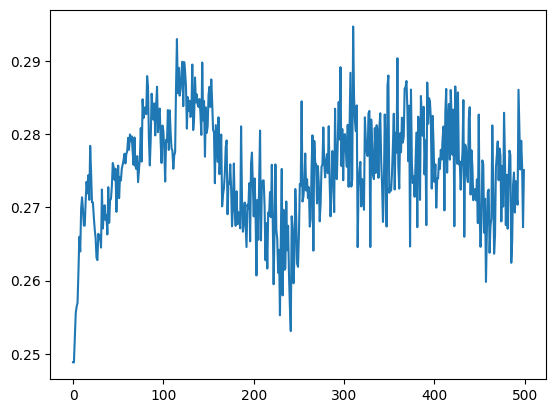

In [28]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])